# T2: Downstream Proteomics

Analyzing downstream proteomics is fun!  
In this tutorial we will show you how to take a quick look at your data, check the proteomic distributions.  
Filter the dataset to remove low quality proteins, and impute the data for dimensionality reduction.  
Then we perform some simple statistical test and plot it with the famous volcano plot.

## Introduction

### Package import 

In [1]:
from pathlib import Path

import opendvp as dvp
import pandas as pd
import numpy as np
import scanpy as sc

import seaborn as sns
import matplotlib.pyplot as plt

print(f"openDVP version {dvp.__version__}")

# Downloads the dataset from Zenodo, checks it against a known MD5, and extracts it.
# Cached per user, so re-running this cell is instant and works offline.
paths = dvp.datasets.tutorial_data()

# everything this notebook writes goes here
outputs = Path("../outputs")
outputs.mkdir(parents=True, exist_ok=True)

openDVP version 0.8.0
11:37:01.25 | INFO | Fetching the openDVP tutorial dataset into /Users/jnimoca/Library/Caches/opendvp


/Users/jnimoca/Jose_BI/1_Repositories/openDVP/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


11:37:02.15 | SUCCESS | Tutorial dataset ready at /Users/jnimoca/Library/Caches/opendvp/data.tar.gz.untar/data


### Load DIANN data into an adata object

Mass spectrometers produce spectra of your protein fragments.  
These peaks needs to be mapped to peptides from a database, and then infer the present proteins.

We use [DIANN](https://github.com/vdemichev/DiaNN), a software tool used to streamline this process and obtain a relative quantfication of our proteins.  
We now use one of the `DIANN` outputs, the protein group matrix (`pg_matrix`), to perform downstream analysis.

Therefore, our first step is to convert DIANN to adata.

In [2]:
adata = dvp.io.DIANN_to_adata(
    DIANN_path=paths["proteomics"],
    DIANN_sep="\t",
    metadata_path=paths["proteomics_metadata"],
    metadata_sep=";",
    n_of_protein_metadata_cols=4,
)

11:37:08.71 | INFO | Starting DIANN matrix shape (7030, 14)
11:37:08.71 | INFO | Removing 264 contaminants
11:37:08.71 | INFO | Filtering 3 genes that are NaN
11:37:08.71 | INFO | ['A0A0G2JRQ6_HUMAN', 'A0A0J9YY99_HUMAN', 'YJ005_HUMAN']
11:37:08.72 | INFO | 10 samples, and 6763 proteins
11:37:08.72 | INFO | 52 gene lists (eg 'TMA7;TMA7B') were simplified to ('TMA7').
11:37:08.72 | SUCCESS | Anndata object has been created :) 


This function performs of helpful functionalities under the hood:
1. It removes known [contaminants](https://github.com/HaoGroup-ProtContLib/Protein-Contaminant-Libraries-for-DDA-and-DIA-Proteomics) from your samples.
2. It removes any protein groups that do not have a valid gene name (NaN)
3. Gene strings like `'TMA7;TMA7B'` are simplified to `TMA7` for streamlining with other tools.

### Quick look at adata object

In [3]:
adata

AnnData object with n_obs × n_vars = 10 × 6763
    obs: 'Precursors.Identified', 'Proteins.Identified', 'Average.Missed.Tryptic.Cleavages', 'LCMS_run_id', 'RCN', 'RCN_long', 'QuPath_class'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'First.Protein.Description'
    layers: None (.X)

In [4]:
# Quantification values, we can see missing values already :)
adata.X[:5, :5]

array([[     nan,  5387.49, 10755.7 , 21750.3 , 20374.3 ],
       [ 9623.48,      nan,      nan,  8450.09,      nan],
       [ 8161.97,      nan,      nan, 14534.7 , 16192.5 ],
       [ 7438.25,      nan,      nan,  7547.04, 13379.7 ],
       [     nan,      nan,  9925.7 , 19308.4 , 16956.7 ]])

In [5]:
# Variable metadata, in this case proteins/genes
adata.var.head()

,Protein.Group,Protein.Names,Genes,First.Protein.Description
Gene,,,,
TMA7,A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B,Translation machinery-associated protein 7B
IGLV8-61,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61
IGLV3-10,A0A075B6K4,LV310_HUMAN,IGLV3-10,Immunoglobulin lambda variable 3-10
IGLV3-9,A0A075B6K5,LV39_HUMAN,IGLV3-9,Immunoglobulin lambda variable 3-9
IGKV2-28,A0A075B6P5;P01615,KV228_HUMAN;KVD28_HUMAN,IGKV2-28;IGKV2D-28,Immunoglobulin kappa variable 2-28


In [6]:
# Observations metadata, in this case each proteomic sample
adata.obs.head()

,Precursors.Identified,Proteins.Identified,Average.Missed.Tryptic.Cleavages,LCMS_run_id,RCN,RCN_long,QuPath_class
Sample_filepath,,,,,,,
E:\Proteomics\Jose\P26E17\rawfiles\Olive_20241204_JoN_Evo2_80SPD_Rplate_P26E17_K20_S6-G4_1_8674.d,26358,4760,0.139,8674,RCN1,Tumor enriched,P12_Tumor_1
E:\Proteomics\Jose\P26E17\rawfiles\Olive_20241129_JoN_Evo2_80SPD_P26E17_991_H21_S3-F9_1_8452.d,24705,4553,0.134,8452,RCN1,Tumor enriched,P12_Tumor_2
E:\Proteomics\Jose\P26E17\rawfiles\Olive_20241129_JoN_Evo2_80SPD_P26E17_991_E4_S2-C2_1_8414.d,26750,4835,0.134,8414,RCN1,Tumor enriched,P12_Tumor_3
E:\Proteomics\Jose\P26E17\rawfiles\Olive_20241204_JoN_Evo2_80SPD_Rplate_P26E17_L10_S4-H8_1_8551.d,24268,4502,0.116,8551,RCN1,Tumor enriched,P12_Tumor_4
E:\Proteomics\Jose\P26E17\rawfiles\Olive_20241129_JoN_Evo2_80SPD_P26E17_991_F4_S2-D2_1_8424.d,27883,4858,0.136,8424,RCN1,Tumor enriched,P12_Tumor_5


## Describing the dataset

This dataset is a subset of the Triple Negative Breast Cancer dataset investigated in the openDVP paper.  
Briefly, we performed image analysis, and based on the recurrent cellular neighborhoods(RCN) we performed our laser microddisection.  
We collected samples from tumor enriched areas and immune enriched areas.  
Here we explore how their proteomes differ.

In [7]:
adata.obs.columns

Index(['Precursors.Identified', 'Proteins.Identified',
       'Average.Missed.Tryptic.Cleavages', 'LCMS_run_id', 'RCN', 'RCN_long',
       'QuPath_class'],
      dtype='object')

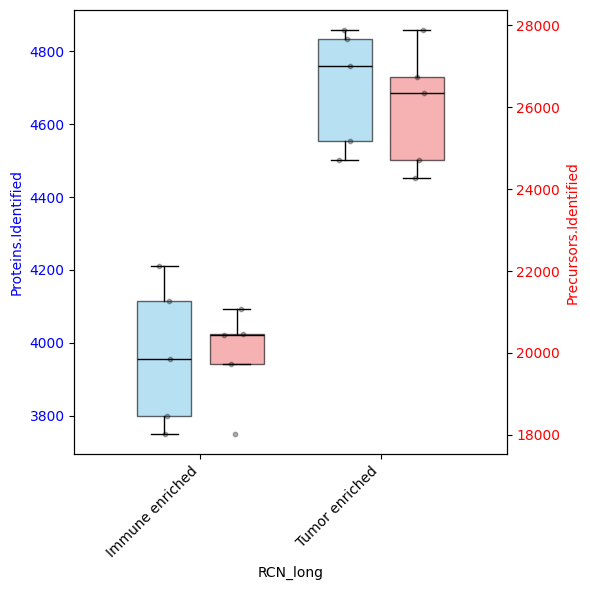

In [8]:
# Let's see how many proteins and precursors were measured per sample
dvp.pl.dual_axis_boxplots(
    adata=adata, feature_1="Proteins.Identified", feature_2="Precursors.Identified", group_by="RCN_long"
)

### Exploring the protein quantification

Modern mass spectrometry workflows have a dynamic range of 5 to 6 orders of magnitude.  
To have a more statistically normal distribution, and have a more intuitive range of data, we use log2 transformation.

In [9]:
print(f"Maximum value: {np.nanmax(adata.X)}")
print(f"Minimum value: {np.nanmin(adata.X)}")

Maximum value: 11506600.0
Minimum value: 251.795


In [10]:
# Log2 transform the data
adata.X = np.log2(adata.X)

In [11]:
print(f"Maximum value: {np.nanmax(adata.X)}")
print(f"Minimum value: {np.nanmin(adata.X)}")

Maximum value: 23.45595826937909
Minimum value: 7.976105824909396


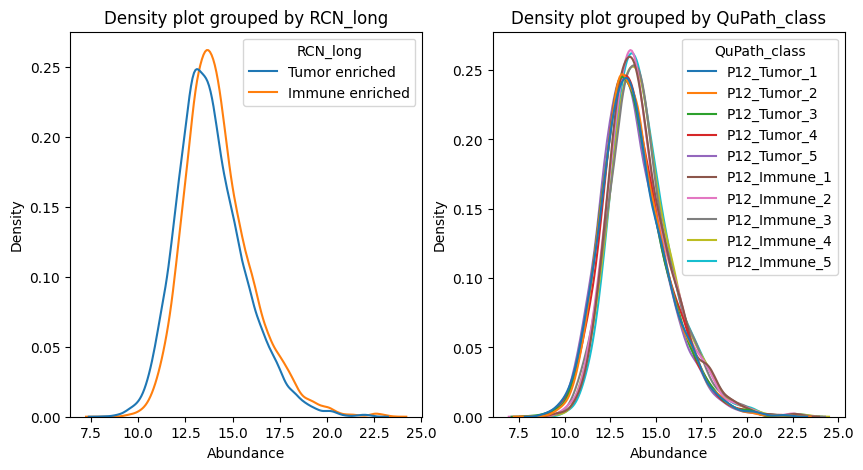

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
dvp.pl.density(adata=adata, color_by="RCN_long", ax=axes[0])
dvp.pl.density(adata=adata, color_by="QuPath_class", ax=axes[1])
plt.show()

These density graphs already show us little difference between samples, in terms of overall quantifications.

11:37:33.42 | INFO | no groups passed, using ['Tumor enriched', 'Immune enriched']


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


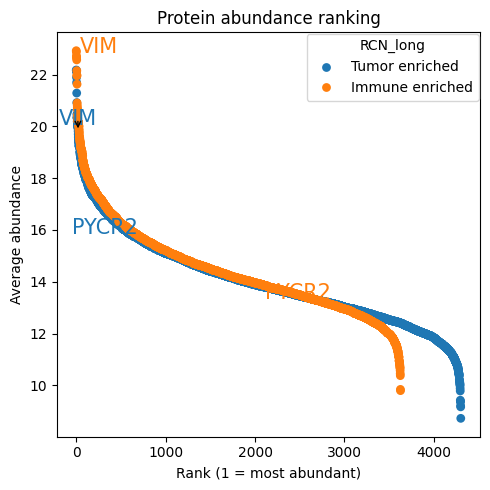

In [13]:
dvp.pl.rankplot(adata=adata, adata_obs_key="RCN_long", min_presence_fraction=0.7, proteins_to_label=["VIM", "PYCR2"])

## Preprocess dataset

### Filter dataset by NaNs

We expect a lot of proteins to be removed because this is a subsampled dataset.  
Many protein hits were present in other groups not present here.

In [14]:
adata_filtered = dvp.tl.filter_features_byNaNs(adata=adata, threshold=0.7, grouping="RCN")

11:37:37.72 | INFO | Filtering protein with at least 70.0% valid values in ANY group
11:37:37.72 | INFO | Calculating overall QC metrics for all features.
11:37:37.72 | INFO | Filtering by groups, RCN: ['RCN1', 'RCN3']
11:37:37.72 | INFO |  RCN1 has 5 samples
11:37:37.73 | INFO |  RCN3 has 5 samples
11:37:37.73 | INFO | Keeping proteins that pass 'ANY' group criteria.
11:37:37.73 | INFO | Complete QC metrics for all initial features stored in `adata.uns['filter_features_byNaNs_qc_metrics']`.
11:37:37.74 | INFO | 4637 proteins were kept.
11:37:37.74 | INFO | 2126 proteins were removed.
11:37:37.74 | SUCCESS | filter_features_byNaNs complete.


In [15]:
adata_filtered.uns["filter_features_byNaNs_qc_metrics"].head()

,Protein.Group,Protein.Names,Genes,First.Protein.Description,overall_mean,overall_nan_count,overall_valid_count,overall_nan_proportions,overall_valid,RCN1_mean,...,RCN1_nan_proportions,RCN1_valid,RCN3_mean,RCN3_nan_count,RCN3_valid_count,RCN3_nan_proportions,RCN3_valid,valid_in_all_groups,valid_in_any_group,not_valid_in_any_group
Gene,,,,,,,,,,,,,,,,,,,,,
TMA7,A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B,Translation machinery-associated protein 7B,13.391,5,5,0.5,False,13.029,...,0.4,False,13.933,3,2,0.6,False,False,False,True
IGLV8-61,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,13.666,6,4,0.6,False,12.395,...,0.8,False,14.090,2,3,0.4,False,False,False,True
IGLV3-10,A0A075B6K4,LV310_HUMAN,IGLV3-10,Immunoglobulin lambda variable 3-10,14.216,6,4,0.6,False,13.335,...,0.6,False,15.097,3,2,0.6,False,False,False,True
IGLV3-9,A0A075B6K5,LV39_HUMAN,IGLV3-9,Immunoglobulin lambda variable 3-9,15.293,0,10,0.0,True,13.680,...,0.0,True,16.906,0,5,0.0,True,True,True,False
IGKV2-28,A0A075B6P5;P01615,KV228_HUMAN;KVD28_HUMAN,IGKV2-28;IGKV2D-28,Immunoglobulin kappa variable 2-28,15.343,1,9,0.1,True,14.014,...,0.2,True,16.407,0,5,0.0,True,True,True,False


In [16]:
adata_filtered.uns["filter_features_byNaNs_qc_metrics"].columns

Index(['Protein.Group', 'Protein.Names', 'Genes', 'First.Protein.Description',
       'overall_mean', 'overall_nan_count', 'overall_valid_count',
       'overall_nan_proportions', 'overall_valid', 'RCN1_mean',
       'RCN1_nan_count', 'RCN1_valid_count', 'RCN1_nan_proportions',
       'RCN1_valid', 'RCN3_mean', 'RCN3_nan_count', 'RCN3_valid_count',
       'RCN3_nan_proportions', 'RCN3_valid', 'valid_in_all_groups',
       'valid_in_any_group', 'not_valid_in_any_group'],
      dtype='object')

In this dataframe, stored away in adata.uns, you can see all th qc metrics of the filtering

In [17]:
# Store filtered adata
dvp.io.export_adata(adata=adata_filtered, path_to_dir=outputs / "checkpoints", checkpoint_name="2_filtered")

11:37:42.04 | INFO | Writing h5ad
11:37:42.09 | SUCCESS | Wrote h5ad file


### Imputation

In [18]:
adata_imputed = dvp.tl.impute_gaussian(adata=adata_filtered, mean_shift=-1.8, std_dev_shift=0.3)

11:37:44.01 | INFO | Storing original data in `adata.layers['unimputed']`.
11:37:44.01 | INFO | Imputation with Gaussian distribution PER PROTEIN
11:37:44.01 | INFO | Mean number of missing values per sample: 572.6 out of 4637 proteins
11:37:44.01 | INFO | Mean number of missing values per protein: 1.23 out of 10 samples
11:37:45.73 | INFO | Imputation complete. QC metrics stored in `adata.uns['impute_gaussian_qc_metrics']`.


In [19]:
adata_imputed

AnnData object with n_obs × n_vars = 10 × 4637
    obs: 'Precursors.Identified', 'Proteins.Identified', 'Average.Missed.Tryptic.Cleavages', 'LCMS_run_id', 'RCN', 'RCN_long', 'QuPath_class'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'First.Protein.Description', 'mean', 'nan_proportions'
    uns: 'filter_features_byNaNs_qc_metrics', 'impute_gaussian_qc_metrics'
    layers: None (.X), 'unimputed'

Like the previous process, the imputation stores two quality control datasets.  
First, the `impute_gaussian_qc_metrics`
Showing you per protein:
- how many values were imputed
- the distribution used
- the values used to impute with

In [20]:
adata_imputed.uns["impute_gaussian_qc_metrics"]

,n_imputed,imputation_mean,imputation_stddev,imputed_values
Gene,,,,
IGLV3-9,0,15.292778,1.840310,NAN
IGKV2-28,1,15.343103,1.346909,[13.0367]
IGHV3-64,6,13.710045,1.247562,"[11.6163, 12.0692, 11.7368, 11.694, 11.6145, 1..."
IGKV2D-29,0,16.213394,1.481762,NAN
IGKV1-27,0,13.452261,1.394043,NAN
...,...,...,...,...
WASF2,0,15.135411,0.255652,NAN
MAU2,1,12.475482,0.455856,[11.7839]
ENPP4,0,12.008373,0.630813,NAN


Second, the unimputed values are stored inside the layers compartment of the adata object.  
This is a backup in case imputation has done something wrong.  
You can always call those values by `adata_imputed.layers['unimputed']`

In [21]:
dvp.io.export_adata(adata=adata_imputed, path_to_dir=outputs / "checkpoints", checkpoint_name="3_imputed")

11:37:52.03 | INFO | Writing h5ad
11:37:52.08 | SUCCESS | Wrote h5ad file


## Let's start with the biology

### PCA (courtesy of Scanpy)

In [22]:
sc.pp.pca(adata_imputed)

Scanpy is a very powerful data analysis package created for single-cell RNA sequencing.  
We use it here because it is very convenient, and it already expects the AnnData format we have.  
Beware of using Scanpy for proteomics datasets, assumptions will vary.

In [23]:
adata_imputed

AnnData object with n_obs × n_vars = 10 × 4637
    obs: 'Precursors.Identified', 'Proteins.Identified', 'Average.Missed.Tryptic.Cleavages', 'LCMS_run_id', 'RCN', 'RCN_long', 'QuPath_class'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'First.Protein.Description', 'mean', 'nan_proportions'
    uns: 'filter_features_byNaNs_qc_metrics', 'impute_gaussian_qc_metrics', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X), 'unimputed'

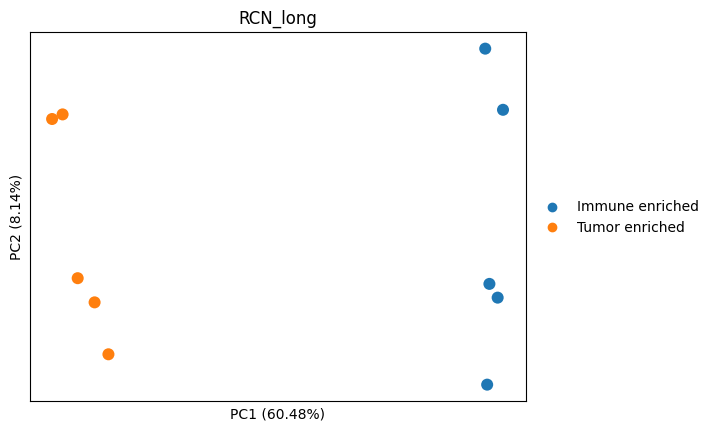

In [24]:
# let's plot it
sc.pl.pca(adata_imputed, color="RCN_long", annotate_var_explained=True, size=300)

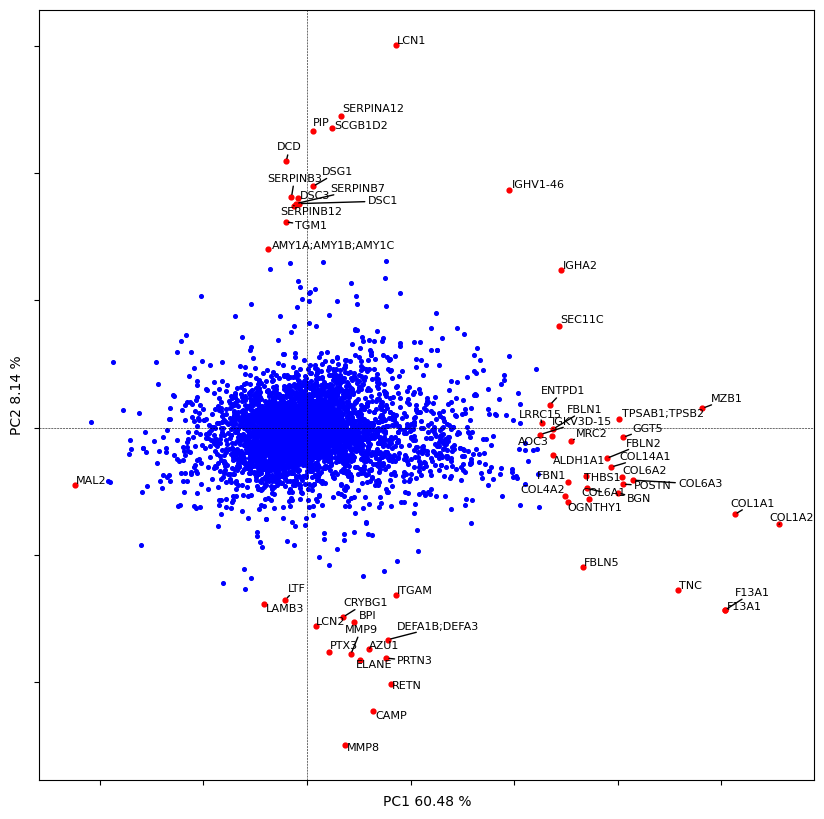

In [25]:
# let's plot the contribution of each protein to the PC1 and PC2
dvp.pl.pca_loadings(adata_imputed)

In [26]:
dvp.io.export_adata(adata=adata_imputed, path_to_dir=outputs / "checkpoints", checkpoint_name="4_pca")

11:38:03.46 | INFO | Writing h5ad
11:38:03.50 | SUCCESS | Wrote h5ad file


### Protein intensities to find patterns at high level

/Users/jnimoca/Jose_BI/1_Repositories/openDVP/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/jnimoca/Jose_BI/1_Repositories/openDVP/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


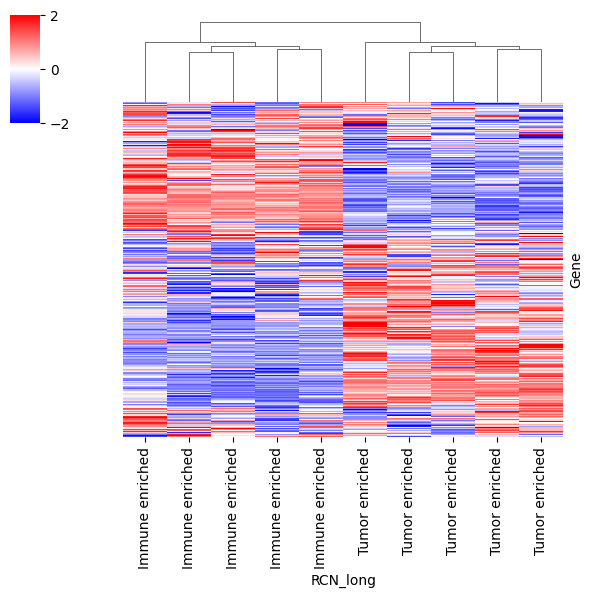

In [27]:
dataframe = pd.DataFrame(data=adata_imputed.X, columns=adata_imputed.var_names, index=adata_imputed.obs.RCN_long)

cm = sns.clustermap(data=dataframe.T, z_score=0, cmap="bwr", vmin=-2, vmax=2, yticklabels=False, figsize=(6, 6))

# to hide dendrogram of proteins
cm.ax_row_dendrogram.set_visible(False)

## Differential analysis

In [28]:
# ttest
adata_DAP = dvp.tl.stats_ttest(
    adata_imputed, grouping="RCN_long", group1="Tumor enriched", group2="Immune enriched", FDR_threshold=0.05
)

11:38:11.57 | INFO | Using pingouin.ttest to perform unpaired two-sided t-test between Tumor enriched and Immune enriched
11:38:11.57 | INFO | Using Benjamini-Hochberg for FDR correction, with a threshold of 0.05
11:38:11.57 | INFO | The test found 2006 proteins to be significantly


In [30]:
adata_DAP

AnnData object with n_obs × n_vars = 10 × 4637
    obs: 'Precursors.Identified', 'Proteins.Identified', 'Average.Missed.Tryptic.Cleavages', 'LCMS_run_id', 'RCN', 'RCN_long', 'QuPath_class'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'First.Protein.Description', 'mean', 'nan_proportions', 't_val', 'p_val', 'mean_diff', 'sig', 'p_corr', '-log10_p_corr'
    uns: 'filter_features_byNaNs_qc_metrics', 'impute_gaussian_qc_metrics', 'pca', 'RCN_long_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X), 'unimputed'

In [31]:
dvp.io.export_adata(adata=adata_DAP, path_to_dir=outputs / "checkpoints", checkpoint_name="5_DAP")

11:38:58.51 | INFO | Writing h5ad
11:38:58.55 | SUCCESS | Wrote h5ad file


### Volcano plot

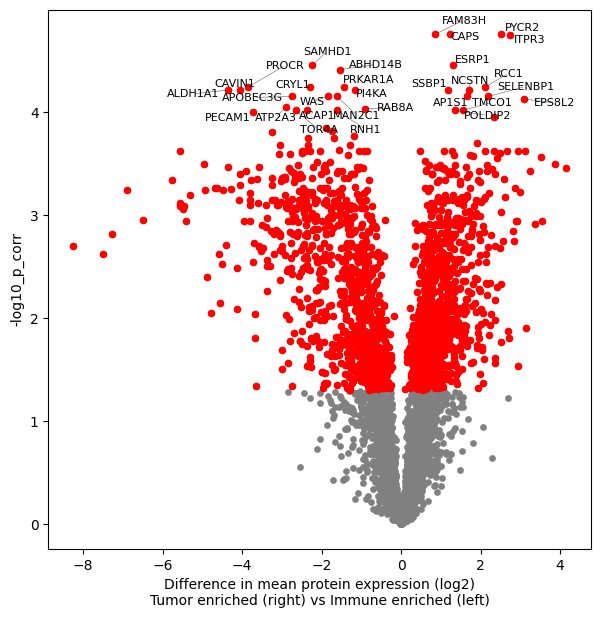

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))
dvp.pl.volcano(
    adata=adata_DAP,
    x="mean_diff",
    y="-log10_p_corr",
    FDR=0.05,
    significant=True,
    tag_top=30,
    group1="Tumor enriched",
    group2="Immune enriched",
    ax=ax,
)